# Operator Dynamics in Random Bricklayer Circuits with Pauli Propagation

The goal of this notebook is to study the time evolution of a local quantum observable using the Pauli propagation framework implemented in `PauliPropagation.jl`.



In [104]:
#using Pkg; Pkg.add("PauliPropagation")
using PauliPropagation

## Validation of Pauli Propagation on Two-Qubit XX Circuits

We focus on a simple and controlled setting in order to validate the method and build intuition before moving to more complex random circuits.

We consider a system of $n$ qubits arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates** applied in a **bricklayer pattern**.

In [105]:
nqubits = 2

topology = bricklayertopology(nqubits; periodic=false)

1-element Vector{Tuple{Int64, Int64}}:
 (1, 2)

Each layer consists of nearest-neighbor gates of the form:

$$
U_{ij} = e^{-i \theta X_i X_j}
$$

where $X_i$ is the Pauli X operator acting on qubit $i$, and $\theta$ is a fixed parameter (Trotter step).


This type of circuit corresponds to a Trotterized time evolution under an XX Hamiltonian:

$$
H = \sum_{\langle i,j \rangle} X_i X_j
$$

In [106]:
function simple_trotter_circuit_XX(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
        topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
        rxxlayer!(circuit, topology)
    end
    return circuit
end

simple_trotter_circuit_XX (generic function with 1 method)

---

## Heisenberg picture

Instead of evolving a quantum state, we study the evolution of an observable $O$ in the Heisenberg picture:

$$
O(t) = U^\dagger O U
$$

In this notebook, we choose as initial observable a local Pauli operator:

$$
O = Z_i
$$

In [107]:
i = 1
Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i

PauliString(nqubits: 2, 1.0 * ZI)

---

## Pauli propagation method

The key idea of Pauli propagation is to express the observable as a sum of Pauli strings:

$$
O = \sum_\alpha c_\alpha P_\alpha
$$

and to propagate each Pauli string through the circuit.

Under conjugation by quantum gates, Pauli strings transform into linear combinations of other Pauli strings. This leads to a growth in the number of terms, which is controlled in practice using:

- truncation of small coefficients
- limitation of the Pauli weight

This method is particularly efficient when the operator remains relatively sparse in the Pauli basis.

Here we want to verify the implementation : we don't apply truncation.

In [108]:
# the truncations
max_weight = typemax(Int)   # no limit          in the documentation they put = 6
min_abs_coeff = 0.0         # no truncations                  """             = 1e-4

0.0

---

## The propagation in our Circuit

In [110]:
nlayers = 5
circuit = simple_trotter_circuit_XX(nqubits, nlayers; topology)

dt = 0.1 # time step
parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value

# propagate through the circuit
pauli_sum = propagate(circuit, observable, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 2, 2 Pauli terms:
 0.47943 * YX
 0.87758 * ZI
)

---

## Result

In [111]:
pauli_sum

PauliSum(nqubits: 2, 2 Pauli terms:
 0.47943 * YX
 0.87758 * ZI
)

If we calculate the same circuit analytically and compare our results, see [validation_twoQubit_XX_circuit.py](https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/heisenberg-picture/pauli-propagation/validation_twoQubit_XX_circuit.py), we obtain virtually the same result, barring a numerical error of $10^{-5}$.

---

## Pauli Entropy

For an observable express as a sum of Pauli strings, we define the Pauli Entropy:

$$ S = - \sum_\alpha c_\alpha log(c_\alpha)$$

In [109]:
function pauli_entropy(pauli_sum::PauliSum)
    return sum(((P, c),) -> c > 0 ? -c * log(c) : 0.0, pauli_sum)
end

pauli_entropy (generic function with 1 method)

In [143]:
nqubits = 8
i = 4
Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i

nlayers = 200

circuit = simple_trotter_circuit_XX(nqubits, nlayers; topology)
dt = 0.1 # time step
parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value

entropy = Float64[]
for l in 1:nlayers
    subcircuit = simple_trotter_circuit_XX(nqubits, l; topology=topology)
    pauli_sum = propagate(subcircuit, observable, parameters[1:countparameters(subcircuit)];
                          max_weight, min_abs_coeff)
    S = pauli_entropy(pauli_sum)
    push!(entropy, S)
end

println(pauli_sum)

PauliSum(nqubits: 8, 4 Pauli terms:
 0.37258 * IIIYXIII
 0.37258 * IIXYIIII
 -0.83346 * IIXZXIII
 0.16648 * IIIZIIII
)


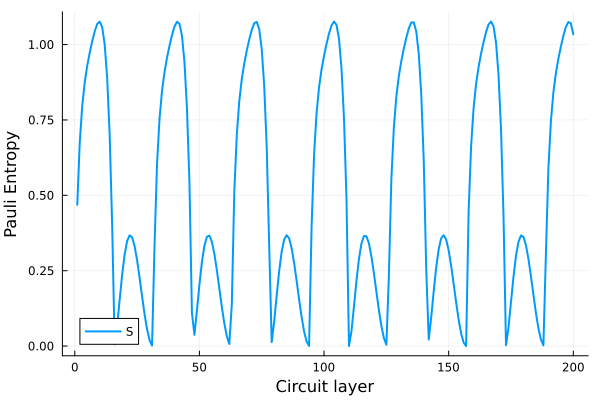

In [144]:
using Plots

plot(1:nlayers, entropy,
     xlabel="Circuit layer",
     ylabel="Pauli Entropy",
     label="S",
     lw=2)

---

## Random Gate

In a second stage, we will generalize this setup to random circuits of the form:

$$
U = \prod_j e^{i \theta_j P_j}
$$

where:

- $\theta_j$ are random angles
- $P_j$ are random two-qubit Pauli strings


In [129]:
nqubits = 6

topology = bricklayertopology(nqubits; periodic=false)

# the truncations
max_weight = 6
min_abs_coeff = 1e-4

0.0001

In [136]:
function random_pauli_layer!(circuit, topology)
    for (i, j) in topology
        r = rand()
        if r < 1/3
            append!(circuit, rxxlayer!(Gate[], [(i,j)]))
        elseif r < 2/3
            append!(circuit, ryylayer!(Gate[], [(i,j)]))
        else
            append!(circuit, rzzlayer!(Gate[], [(i,j)]))
        end
    end
end

function random_pauli_layer2!(circuit, topology)
    for (i, j) in topology
        tmp = Gate[]
        r = rand()

        if r < 1/3
            rxxlayer!(tmp, [(i,j)])
        elseif r < 2/3
            ryylayer!(tmp, [(i,j)])
        else
            rzzlayer!(tmp, [(i,j)])
        end

        append!(circuit, tmp)
    end
end

function random_trotter_circuit(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
        topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
        random_pauli_layer!(circuit, topology)
    end

    return circuit
end

random_trotter_circuit (generic function with 1 method)

In [137]:
nlayers = 200

circuit = random_trotter_circuit(nqubits, nlayers; topology)

1000-element Vector{Gate}:
 PauliRotation([:X, :X], [1, 2])
 PauliRotation([:X, :X], [3, 4])
 PauliRotation([:X, :X], [5, 6])
 PauliRotation([:Y, :Y], [2, 3])
 PauliRotation([:Z, :Z], [4, 5])
 PauliRotation([:X, :X], [1, 2])
 PauliRotation([:Z, :Z], [3, 4])
 PauliRotation([:Z, :Z], [5, 6])
 PauliRotation([:Y, :Y], [2, 3])
 PauliRotation([:X, :X], [4, 5])
 PauliRotation([:Z, :Z], [1, 2])
 PauliRotation([:Y, :Y], [3, 4])
 PauliRotation([:Z, :Z], [5, 6])
 ⋮
 PauliRotation([:Z, :Z], [2, 3])
 PauliRotation([:Y, :Y], [4, 5])
 PauliRotation([:X, :X], [1, 2])
 PauliRotation([:X, :X], [3, 4])
 PauliRotation([:Z, :Z], [5, 6])
 PauliRotation([:Z, :Z], [2, 3])
 PauliRotation([:Z, :Z], [4, 5])
 PauliRotation([:X, :X], [1, 2])
 PauliRotation([:X, :X], [3, 4])
 PauliRotation([:X, :X], [5, 6])
 PauliRotation([:Z, :Z], [2, 3])
 PauliRotation([:Y, :Y], [4, 5])

In [132]:
parameters = randn(countparameters(circuit)) .* 2π # random thetas

1000-element Vector{Float64}:
  0.2620060333665268
  1.8340062976295506
 -3.064670901225511
 -2.3478482733292627
 -8.992734974519703
 -7.401335127720851
 -6.833133005093857
 10.939836298338529
 -1.1295963647435165
 -2.889457102822499
 -0.838779283898195
 -2.8793149388976653
  6.959257067524271
  ⋮
 -3.6468399088069727
 -0.13786368250023218
 -3.096784298747409
  7.323036637250675
 -3.1737422395925203
 -1.9915141928756805
  0.024346229911856938
 -4.699736921143557
 -3.588075974688483
 -6.403647904425806
 -3.0689093806989356
 -2.6307165198309486

In [133]:
# propagate through the circuit
pauli_sum = propagate(circuit, observable, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 2, 254 Pauli terms:
 0.034843 * IY
 -0.027801 * ZI
 0.067285 * YZ
 0.038891 * IZ
 0.003528 * IZ
 -0.066683 * YZ
 -0.091364 * YX
 0.11205 * YY
 0.014283 * ZI
 0.0083201 * ZX
 -0.061045 * ZY
 -0.069195 * XY
 0.044937 * ZY
 0.060092 * XZ
 0.046627 * IX
 -0.0057502 * YY
 -0.10059 * YX
 -0.028355 * XY
 0.037704 * II
 -0.070597 * ZI
  ⋮)

Let $P$ a Pauli string and $\theta$ a real number.


$$e^{i\theta P} = \sum_{k=0}^{\infty} \frac{(i\theta P)^{2k}}{(2k)!} + \sum_{k=0}^{\infty} \frac{(i\theta P)^{2k+1}}{(2k+1)!}$$

- $(i\theta P)^{2k} = i^{2k} \theta^{2k} P^{2k} = (-1)^k \theta^{2k} (P^2)^k$. By definition  $P^2 = \mathbb I$, so $P^{2k} = \mathbb I$.
- $(i\theta P)^{2k+1} = i^{2k+1} \theta^{2k+1} P^{2k+1} = i(-1)^k \theta^{2k+1} P$.

$$\implies e^{i\theta P} = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k} \mathbb I}{(2k)!} + \sum_{k=0}^{\infty} \frac{i (-1)^k \theta^{2k+1} P}{(2k+1)!}$$

$$\implies e^{i\theta P} = \mathbb I \left( \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k}}{(2k)!} \right) + i P \left( \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k+1}}{(2k+1)!} \right)$$

And we know :

- $\cos(\theta) = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k}}{(2k)!}$
- $\sin(\theta) = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k+1}}{(2k+1)!}$

$$\implies e^{i\theta P} = \cos(\theta) \mathbb I + i \sin(\theta) P \qquad \forall P \in \text{Pauli string, } \forall \theta \in \mathbb R$$


---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl